In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn

# Van Der Polle Equation (Waffle here)

Now we condider solving an initial vcalue problem. Specifically the Van Der Polle equation. 

* ODE of the form ($\mu$ varies):
$$ \ddot{x} - \mu (1 - x^{2}) \dot{x} + x = 0$$

* Subject to initial conditions:
$$ x(0) = 1 $$
$$ \dot{x}(0) = 0 $$


It is difficult to find an anaylitical solution to this equation, so instead we will use a numerical method (specifically use SolveIVP) for comparison to our learned PINN solution. 

# Numerical Method Solution

In [2]:
def solve_VDP(mu, x0=1, x_p0=0, T=10, n_eval=1000):

    def VDP(t, y):
        x, x_p = y
        x_pp = mu*(1 - x**2)*x_p - x
        return [x_p, x_pp]

    t_span = (0.0, T)
    t_eval = np.linspace(0, T, n_eval)

    sol = solve_ivp(
        VDP,
        t_span,
        y0=[x0, x_p0],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12,
    )

    return sol.t, sol.y[0], sol.y[1], sol

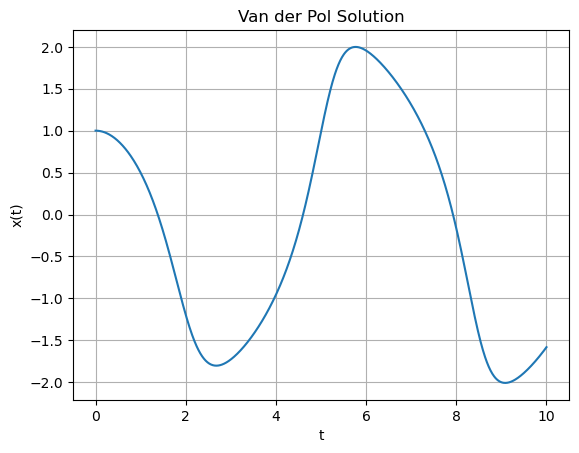

In [3]:
mu = 1
x0 = 1 
x_p0 = 0
T = 10
n_eval = 1000

t, x, v, sol = solve_VDP(mu, x0, x_p0, T, n_eval)

# ---- Plot x(t) ----
plt.figure()
plt.plot(t, x)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Van der Pol Solution")
plt.grid(True)
plt.show()

# PINN Solution

As with previous attempts we will use method of deep functional connections to define our loss function here. 

* Define $\bar{x}$:

$$\bar{x} = \hat{x}(t) + x_0 - \hat{x}(0) + t(x_1 - \hat{x}^{'}(0))$$

Where as in previous cases our loss function now does not contain the boundary conditions.

In [85]:
# Training data
N_t = 1000

# Interior points (exclude boundaries)
t_interior_np = np.linspace(0, 10, N_t + 2)[1:]   # remove 0 
t_interior = torch.tensor(t_interior_np, dtype=torch.float32).view(-1,1)

t_interior.requires_grad_(True)

x0 = torch.tensor([[1.0]], requires_grad=True)
x_p0 = torch.tensor([[0.0]], requires_grad=True)
t0 = torch.tensor([[0.0]], requires_grad=True)
mu = torch.tensor([[1.0]], requires_grad=True)


In [86]:
class BasicNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 100),
            nn.Tanh(),
            nn.Linear(100, 100),
            nn.Tanh(),
            nn.Linear(100, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1),
        )

    def forward(self, x):
        return self.net(x)

# Derivative Helpers
def d_dt(x, t):
    (dt,) = torch.autograd.grad(x, t, grad_outputs=torch.ones_like(x), create_graph=True)
    return dt

def d2_dt2(x, t):
    dt = d_dt(x, t)
    dtt = d_dt(dt, t)
    return dtt

# y bar transformation
def IVP_transform(model, t, x0, x_p0, t0):
     x_hat_t = model(t)

     x_hat_0 = model(t0)
     xp_hat_0 = d_dt(x_hat_0, t0)
     
     # x_bar
     x_bar = x_hat_t + x0 - x_hat_0 + t * (x_p0 - xp_hat_0)
     return x_bar


## Train Model

Very Interetsing Phenomina occurs here with the loss being relatively stationary. Until a sudden rapid drop in the loss. Because early in training, the network learns a smooth approximation that reduces the residual somewhat but does not capture oscillations correctly. That solution is “locally good” in terms of residual but not globally correct.

In [87]:
torch.manual_seed(0)
IVP_model = BasicNetwork()

In [88]:
optimizer = torch.optim.Adam(IVP_model.parameters(), lr=1e-3)

epoch = 15000
losses = []
for i in range(epoch):
    
    x_hat = IVP_transform(IVP_model, t_interior, x0, x_p0, t0)
    
    # 2) residual: y'' + y - sin(pi x)
    x_pp_hat = d2_dt2(x_hat, t_interior)
    x_p_hat = d_dt(x_hat, t_interior)
    
    r = x_pp_hat - mu * (1 - x_hat**2) * x_p_hat + x_hat

    loss = torch.mean(r**2)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    # print every 10 epochs
    if i % 1000 == 0:
        print(f'Epoch: {i} and loss: {loss}')

Epoch: 0 and loss: 0.4209461808204651
Epoch: 1000 and loss: 0.1498745232820511
Epoch: 2000 and loss: 0.14960165321826935
Epoch: 3000 and loss: 0.14957034587860107
Epoch: 4000 and loss: 0.14968205988407135
Epoch: 5000 and loss: 0.14953002333641052
Epoch: 6000 and loss: 0.1494935154914856
Epoch: 7000 and loss: 0.14940254390239716
Epoch: 8000 and loss: 0.14928734302520752
Epoch: 9000 and loss: 0.14887838065624237
Epoch: 10000 and loss: 0.1503005027770996
Epoch: 11000 and loss: 0.14752624928951263
Epoch: 12000 and loss: 0.14943964779376984
Epoch: 13000 and loss: 0.14332789182662964
Epoch: 14000 and loss: 0.00014939412358216941


## Plot

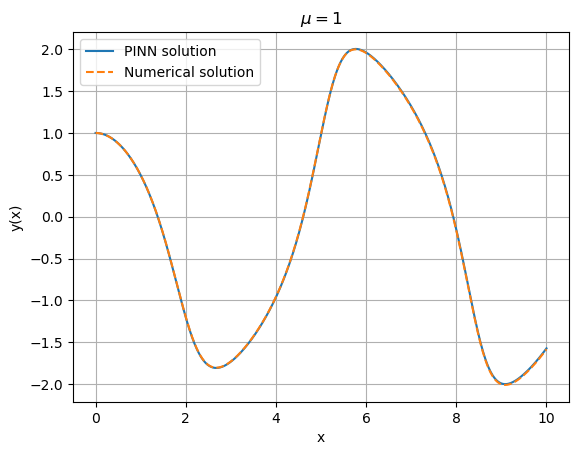

In [94]:
# Create fine grid for plotting
t_plot = torch.linspace(0, 10, 1000).view(-1, 1)

IVP_model.eval()

x_hat_plot =  IVP_transform(IVP_model, t_plot, x0, x_p0, t0)

# Convert to numpy
t_np = t_plot.numpy().ravel()
x_pinn = x_hat_plot.detach().cpu().numpy().ravel()

# Numerical solution
n_eval = 1000
t, x, v, sol = solve_VDP(mu=float(mu), x0=float(x0), x_p0=float(x_p0), T=T, n_eval=n_eval)

# Plot
plt.figure()
plt.plot(t_np, x_pinn, label="PINN solution")
plt.plot(t, x, "--", label="Numerical solution")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.title(rf"$\mu = 1$")
plt.grid(True)
plt.legend()
plt.show()

# See how PINN operates outside of the training data

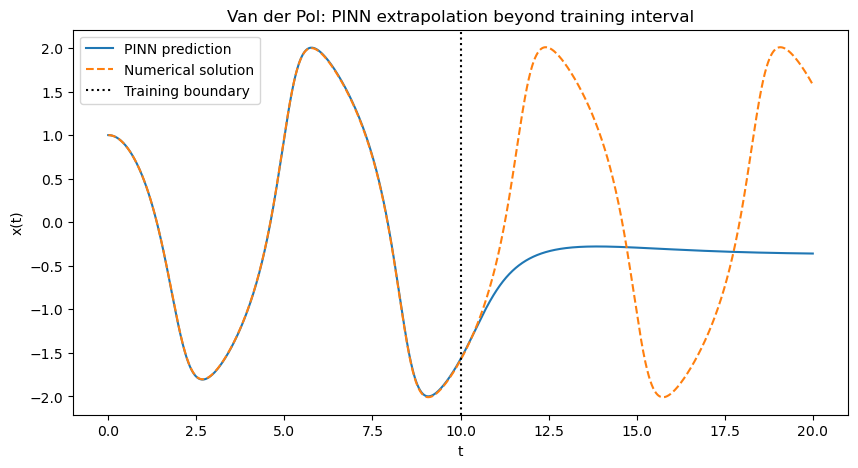

In [95]:
T_test = 20.0
n_eval = 2000

t_num, x_num, v_num, sol = solve_VDP(
    mu=float(mu),
    x0=float(x0),
    x_p0=float(x_p0),
    T=T_test,
    n_eval=n_eval
)

t_plot = torch.tensor(t_num, dtype=torch.float32).view(-1, 1)

IVP_model.eval()

x_hat_plot = IVP_transform(IVP_model, t_plot, x0, x_p0, t0)
x_pinn = x_hat_plot.detach().cpu().numpy().ravel()

plt.figure(figsize=(10,5))

plt.plot(t_num, x_pinn, label="PINN prediction")
plt.plot(t_num, x_num, "--", label="Numerical solution")


plt.axvline(10, color='k', linestyle=':', label="Training boundary")

plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.title("Van der Pol: PINN extrapolation beyond training interval")
plt.show()